# VPP Dispatch — Single Customer Quick Start

This notebook walks through the **legacy single-customer dispatch path**: a fixed default fleet (1 PV array, 1 battery, 1 flexible EV-style load, 1 grid connection) optimized against a price forecast.

It calls `run_dispatch_from_live_input` directly (no HTTP server needed) so it can run anywhere this package is importable.

In [1]:
import sys
sys.path.insert(0, '..')  # so `src.vpp_dispatch` is importable when run from examples/

import numpy as np
import matplotlib.pyplot as plt

from src.vpp_dispatch.models.schemas import LiveCustomerInput
from src.vpp_dispatch.services.dispatch_service import run_dispatch_from_live_input

## 1. Build a 24-hour forecast

Synthetic PV, load, and time-of-use price profiles.

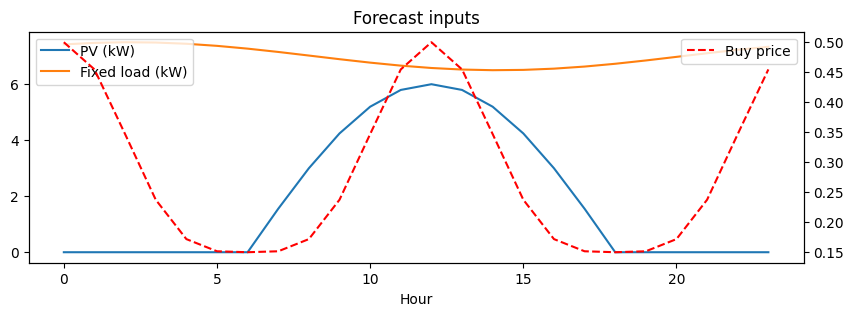

In [2]:
T = 24
hours = np.arange(T)

pv_kw = np.clip(6 * np.sin((hours - 6) / 12 * np.pi), 0, None)
fixed_load_kw = 7.0 + 0.5 * np.sin(hours / 24 * 2 * np.pi + 1)
price_buy = 0.15 + 0.35 * (np.sin((hours - 18) / 24 * 2 * np.pi) ** 4)
price_sell = np.full(T, 0.05)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(hours, pv_kw, label='PV (kW)')
ax.plot(hours, fixed_load_kw, label='Fixed load (kW)')
ax2 = ax.twinx()
ax2.plot(hours, price_buy, color='red', linestyle='--', label='Buy price')
ax.set_xlabel('Hour')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
ax.set_title('Forecast inputs')
plt.show()

## 2. Run dispatch

This solves a mixed-integer LP with Pyomo + HiGHS behind the scenes.

In [3]:
payload = LiveCustomerInput(
    customer_id='notebook_customer',
    pv_kw=pv_kw.tolist(),
    fixed_load_kw=fixed_load_kw.tolist(),
    price_buy=price_buy.tolist(),
    price_sell=price_sell.tolist(),
)

results, status = run_dispatch_from_live_input(payload)
print(status)
print('Objective (net cost):', round(results['objective'], 3))

{'success': True, 'solver': 'highs', 'status': 'optimal', 'termination_condition': 'optimal', 'time_seconds': 0.0, 'tried_solvers': ['highs']}
Objective (net cost): 29.17


In [4]:
print(results)

{'p_grid': [3.620735492403948, 7.476319541585163, 7.499443201162609, 7.488530631949738, 7.444325507504534, 7.369840334005515, 12.27015115293407, 9.02018997819988, 4.023590015100586, 2.374024727256018, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.555674492495467, 5.077245395379359, 18.72984884706593, 17.26900101434289, 6.976409984899415, 7.106479207579648, 4.629292048228538, 2.3364790147136807], 'p_ch': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 5.0, 3.4210526315789473, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 5.0, 3.4210526315789473, 0.0, 0.0, 0.0, 0.0], 'p_dis': [3.8000000000000003, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2768553780450483, 1.5745555290648294, 0.8679660275519092, 0.5792645075960516, 0.7281255006804273, 1.3044043761307593, 2.2688286809309766, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.6000000000000005, 5.0], 'soc': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 5.75, 9.0, 9.0, 8.70857328626837, 7.05114641356855, 6.137497963513909, 5.527745850254908, 4.761297954801827, 3.388240716769449, 1.0, 1.0, 1.0, 5.75, 9.

## 3. Visualize the dispatch schedule

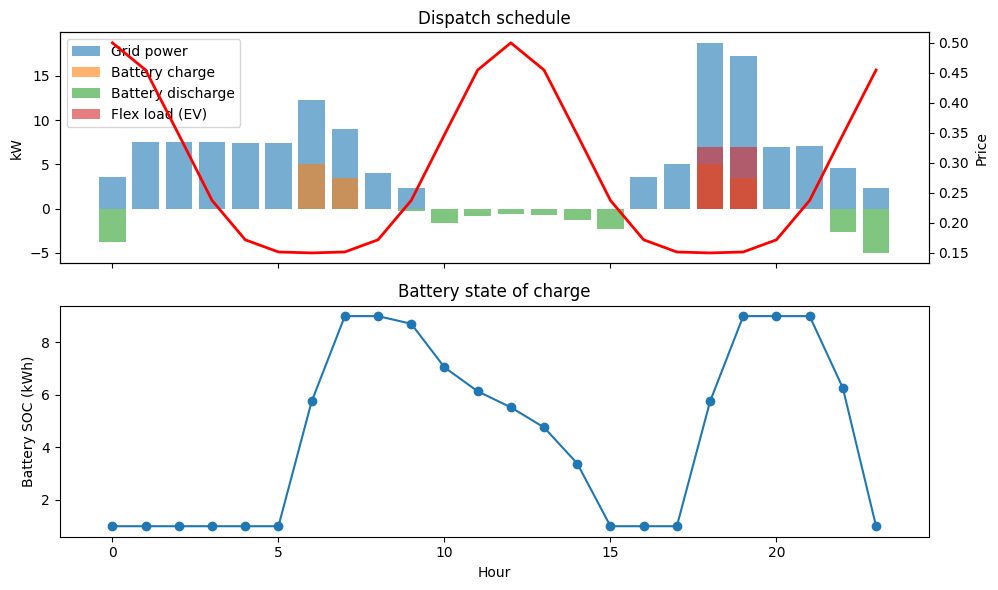

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].bar(hours, results['p_grid'], label='Grid power', alpha=0.6)
axes[0].bar(hours, results['p_ch'], label='Battery charge', alpha=0.6)
axes[0].bar(hours, [-d for d in results['p_dis']], label='Battery discharge', alpha=0.6)
axes[0].bar(hours, results['flex_ev'], label='Flex load (EV)', alpha=0.6)
axes[0].set_ylabel('kW')
axes[0].legend(loc='upper left')
axes[0].set_title('Dispatch schedule')

ax2 = axes[0].twinx()
ax2.plot(hours, price_buy, color='red', linewidth=2, label='Buy price')
ax2.set_ylabel('Price')

axes[1].plot(hours, results['soc'], marker='o')
axes[1].set_ylabel('Battery SOC (kWh)')
axes[1].set_xlabel('Hour')
axes[1].set_title('Battery state of charge')

plt.tight_layout()
plt.show()

## 4. Sanity check

The battery should tend to charge during cheap periods and discharge during expensive ones — a useful smoke test any time the optimization engine changes.

In [6]:
cheapest_hours = np.argsort(price_buy)[:6]
expensive_hours = np.argsort(price_buy)[-6:]

charge_in_cheap = sum(results['p_ch'][h] for h in cheapest_hours)
discharge_in_expensive = sum(results['p_dis'][h] for h in expensive_hours)

print(f'Charging during 6 cheapest hours: {charge_in_cheap:.2f} kWh total')
print(f'Discharging during 6 most expensive hours: {discharge_in_expensive:.2f} kWh total')
assert charge_in_cheap > 0 or discharge_in_expensive > 0, 'Expected price-responsive behaviour'
print('OK: battery dispatch responds to the price signal.')

Charging during 6 cheapest hours: 16.84 kWh total
Discharging during 6 most expensive hours: 10.98 kWh total
OK: battery dispatch responds to the price signal.
